# Vorlage Plausi-Tests

Der bisherige Datensatz OD4117 (Fertilitätsrate nach Alter und Herkunft der Mutter) wurde am 15.05.2025 neu aufgeteilt in vier neue Datensätze:
 - [od411a: Fertilitätsrate nach Jahr](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a)
 - [od411b: Fertilitätsrate nach Jahr und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b)
 - [od411c: Fertilitätsrate nach Jahr und Alter der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c)
 - [od411d: Fertilitätsrate nach Jahr, Alter und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d)
 
### Kurzbeschreibung
Wochenaufenthalter/-innen in der Stadt Zürich, nach Altersklasse, Herkunft, Stadtquartier, Stadtkreis, Zuzugskanton und Zuzugsbezirk, seit 1993

Datum: 15.05.2025


Dataset auf PROD-Datakatalog: Link 

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alter_herkunft_od411a


### Importiere die notwendigen Packages

In [29]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [30]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [31]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [32]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [33]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [34]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
#pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [35]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [36]:
package_name = "bev_fertilitaet_jahr_alter_herkunft_od4117"

#### Import frühere bisherige Datenstruktur

data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV411OD4117"    
    , datums_attr = ['StichtagDatJahr']
    )

#### Import OD411A

In [37]:
package_name_a = "bev_fertilitaet_jahr_od411a"

df_od411a = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_a
    , dataset_name = "BEV411OD411A"    
    , datums_attr = ['StichtagDatJahr']
    )

df_od411a.head(3)

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a/download/BEV411OD411A.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_od411a 

data_source: web


,StichtagDatJahr,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
0,1886-01-01,2455,NaN,NaN
1,1887-01-01,2482,NaN,NaN
2,1888-01-01,2498,NaN,NaN


#### Import OD411B

In [38]:
package_name_b = "bev_fertilitaet_jahr_herkunftm_od411b"

df_od411b = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_b
    , dataset_name = "BEV411OD411B"    
    , datums_attr = ['StichtagDatJahr']
    )

df_od411b.head(3)

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b/download/BEV411OD411B.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_herkunftm_od411b 

data_source: web


,StichtagDatJahr,HerkunftMutterCd,HerkunftMutterLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
0,1920-01-01,1,Schweizerinnen,2505,53575.0,46.8
1,1920-01-01,2,Ausländerinnen,543,18653.0,29.1
2,1921-01-01,1,Schweizerinnen,2506,NaN,NaN


#### Import OD411C

In [39]:
package_name_c = "bev_fertilitaet_jahr_alterm_od411c"

df_od411c = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_c
    , dataset_name = "BEV411OD411C"    
    , datums_attr = ['StichtagDatJahr']
    )

df_od411c.head(3)

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c/download/BEV411OD411C.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_od411c 

data_source: web


,StichtagDatJahr,AlterVMutterSpez1Cd_noDM,AlterVMutterSpez1Lang_noDM,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
0,1920-01-01,1,15- bis 24-Jährige,721,22986.0,31.4
1,1920-01-01,2,25- bis 29-Jährige,1104,12553.0,87.9
2,1920-01-01,3,30- bis 34-Jährige,702,10646.0,65.9


#### Import OD411D

In [40]:
package_name_d = "bev_fertilitaet_jahr_alterm_herkunftm_od411d"

df_od411d = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_d
    , dataset_name = "BEV411OD411D"    
    , datums_attr = ['StichtagDatJahr']
    )

df_od411d.sort_values(['StichtagDatJahr', 'HerkunftMutterCd'], ascending=[False, True]).head(5).T

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d/download/BEV411OD411D.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_herkunftm_od411d 

data_source: web


,930,932,934,936,938
StichtagDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00
HerkunftMutterCd,1,1,1,1,1
HerkunftMutterLang,Schweizerinnen,Schweizerinnen,Schweizerinnen,Schweizerinnen,Schweizerinnen
AlterVMutterSpez1Cd_noDM,1,2,3,4,5
AlterVMutterSpez1Lang_noDM,15- bis 24-Jährige,25- bis 29-Jährige,30- bis 34-Jährige,35- bis 39-Jährige,40- bis 49-Jährige
AnzGebuWir,72,204,880,898,270
Frauen15bis49_noDM,15990.0,12018.0,12293.0,11376.0,21912.0
Fertilitaetsrate_noDM,4.5,17.0,71.6,78.9,12.3


 - [od411a: Fertilitätsrate nach Jahr](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_b<ev_fertilitaet_jahr_alter_herkunft_od411a>)
 - [od411b: Fertilitätsrate nach Jahr und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b)
 - [od411c: Fertilitätsrate nach Jahr und Alter der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c)
 - [od411d: Fertilitätsrate nach Jahr, Alter und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d)

In [ ]:
#obsolet:
# data2betested.sort_values(['StichtagDatJahr', 'ThemaCd'], ascending=False).head(4).T

Berechne weitere Attribute falls notwendig

In [ ]:
#obsolet
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

ThemaCd                            int64
ThemaLang                         object
StichtagDatJahr           datetime64[ns]
HerkunftMutterCd                   int64
HerkunftMutterLang                object
AlterVMutterKlasseCd               int64
AlterVMutterKlasseLang            object
AnzGebuWir                         int64
Frauen15bis49_noDM               float64
Fertilitaetsrate_noDM            float64
StichtagDatJahr_str               object
Jahr                      datetime64[ns]
Jahr_end                  datetime64[ns]
Jahr_nbr                           int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [ ]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

data_max_date = str(max(df_od411a.StichtagDatJahr).year)
data_min_date = str(min(df_od411a.StichtagDatJahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2024
Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2024


In [ ]:
#data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
#data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')
#print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

### Einfache Datentests

In [ ]:
data2betested = df_od411a

In [ ]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   StichtagDatJahr        131 non-null    datetime64[ns]
 1   Datenquelle_Geburten   131 non-null    object        
 2   Datenquelle_Bestand    96 non-null     object        
 3   AnzGebuWir             131 non-null    int64         
 4   Frauen15bis49_noDM     96 non-null     float64       
 5   Fertilitaetsrate_noDM  96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 25.7 KB


In [ ]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 131 rows (observations) and 6 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [ ]:
data2betested.describe()

,StichtagDatJahr,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
count,131,131.000000,96.000000,96.000000
mean,1959-01-01 04:12:49.465648832,4173.076336,103288.687500,42.646875
min,1894-01-01 00:00:00,2724.000000,36447.000000,29.700000
25%,1926-07-02 12:00:00,3279.000000,93130.750000,36.300000
50%,1959-01-01 00:00:00,4069.000000,106560.500000,40.450000
75%,1991-07-02 12:00:00,5113.000000,114498.000000,46.825000
max,2024-01-01 00:00:00,6147.000000,122321.000000,103.700000
std,NaN,1037.837030,14699.241705,11.209422


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [ ]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [ ]:
data2betested.index.year.unique()

Index([1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903,
       ...
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr', length=131)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [ ]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,Datenquelle_Geburten,Datenquelle_Bestand
count,131,96
unique,8,32
top,SSZ-Tabellensammlung,"Statistik Stadt Zürich, BVS"
freq,37,32


Beschreibe numerische Attribute

In [ ]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
count,131,96,96
mean,"4,173","103,289",43
std,"1,038","14,699",11
min,"2,724","36,447",30
25%,"3,279","93,131",36
50%,"4,069","106,560",40
75%,"5,113","114,498",47
max,"6,147","122,321",104


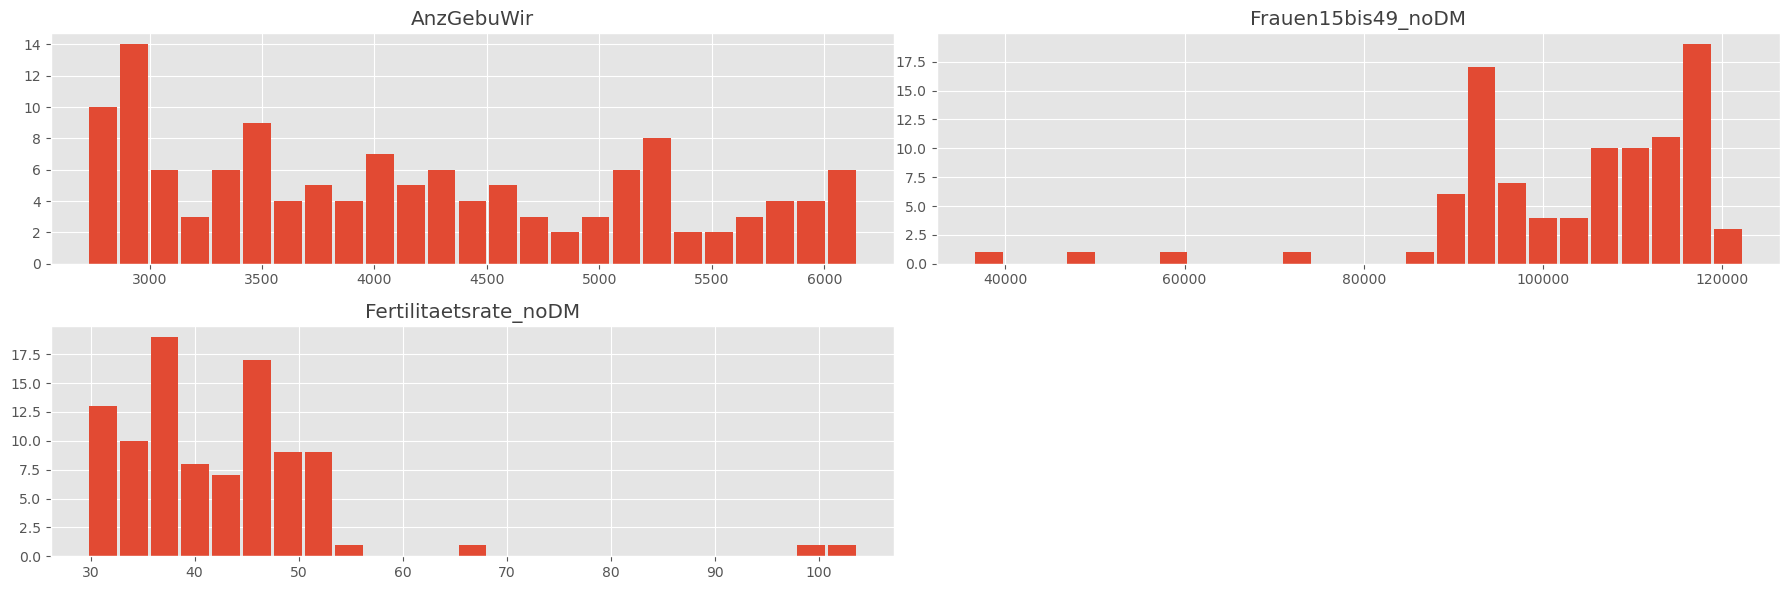

In [ ]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [ ]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated(keep=False)]
duplicate_rows

,Datenquelle_Geburten,Datenquelle_Bestand,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
StichtagDatJahr,,,,,
1926-01-01,"Ehe, Geburt und Tod, 1876 bis 1933, Seite 43*",NaN,2853,NaN,NaN
1927-01-01,"Ehe, Geburt und Tod, 1876 bis 1933, Seite 43*",NaN,2853,NaN,NaN


### Nullwerte und Missings?

In [ ]:
data2betested.isnull().sum()

Datenquelle_Geburten      0
Datenquelle_Bestand      35
AnzGebuWir                0
Frauen15bis49_noDM       35
Fertilitaetsrate_noDM    35
dtype: int64

In den Metadaten beschrieben:
> "Bei den Geburtenzahlen der Jahr 1894, 1900 und 1910 nach Alter der Mutter waren bloss Mittelwerte über mehrere Jahre verfügbar (1894: Mittelwert der Geburten 1893 bis 1895; 1900: Mittelwert der Geburten 1899 bis 1902; 1910: Mittelwert der Geburten 1909 bis 1912). Quelle: Statistisches Jahrbuch der Stadt Zürich, Jahre 1912 und 1913. Die Geburtenzahlen dieser Jahre nach Alter der Mutter wurden auf ganze Zahlen gerunden; die Fertilitätsrate wurde jedoch noch vor dem Runden berechnet."

In [ ]:
data2betested[data2betested['Fertilitaetsrate_noDM'].isna()].reset_index() \
    .groupby(['StichtagDatJahr','ThemaLang']) \
    .agg(
        sum_AnzGebuWir = ('AnzGebuWir', 'sum'),
        count = ('AnzGebuWir', 'count')
    ).unstack()

KeyError: 'ThemaLang'

In [ ]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

Anmerkung Alex: Scheinbar kann man die Daten nicht Gruppieren (es geht um die Fertilitätsrate). Der Schlüssel ist wohl die Spalte Thema. Je nach Thema gibt es verschiedene Untergruppierungen, die dazu kommen (Jahr, Herkunft, Alter).

In [ ]:
    #.groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('StichtagDatJahr', ascending=True) 
agg_jahr.reset_index().head(20)

,StichtagDatJahr,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1894-01-01,3578,36447.0,98.2
1,1895-01-01,3800,0.0,NaN
2,1896-01-01,4458,0.0,NaN
3,1897-01-01,4613,0.0,NaN
4,1898-01-01,4834,0.0,NaN
5,1899-01-01,5084,0.0,NaN
6,1900-01-01,4902,47289.0,103.7
7,1901-01-01,4930,0.0,NaN
8,1902-01-01,4637,0.0,NaN
9,1903-01-01,4373,0.0,NaN


In [ ]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('HerkunftMutterCd', ascending=False) 
agg_herk.reset_index().head(10)

KeyError: 'HerkunftMutterCd'

In [ ]:
agg_thema = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['ThemaCd', 'ThemaLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('ThemaCd', ascending=False) 
agg_thema.reset_index().head(10)

KeyError: 'ThemaCd'

In [ ]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterVMutterKlasseCd', 'AlterVMutterKlasseLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('AlterVMutterKlasseCd', ascending=True) 
agg_age.reset_index().head(11)

KeyError: 'AlterVMutterKlasseCd'

In [ ]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'ThemaCd', 'ThemaLang', 'HerkunftMutterCd', 'HerkunftMutterLang',
       'AlterVMutterKlasseCd', 'AlterVMutterKlasseLang', 'AnzGebuWir', 'Frauen15bis49_noDM',
       'Fertilitaetsrate_noDM', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Fertilitätsrate: Thema 4 Fertilität nach Jahr

In [ ]:
data2betested[['ThemaCd','ThemaLang']].reset_index(drop=True).drop_duplicates()

,ThemaCd,ThemaLang
0,4,Fertilität nach Jahr
1,2,Fertilität nach Jahr und Alter der Mutter
2,3,Fertilität nach Jahr und Herkunft der Mutter
3,1,"Fertilität nach Jahr, Alter und Herkunft der M..."


In [ ]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
#myAgg1 = data2betested.loc[data2betested['ThemaCd']==4]
myAgg1 = data2betested
myAgg1.reset_index().head(3)

,StichtagDatJahr,Datenquelle_Geburten,Datenquelle_Bestand,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
0,1894-01-01,"Jahrbuch 1912 und 1913, Seite 431","Jahrbuch 1991, Seite 34",3578,36447.0,98.2
1,1895-01-01,"Jahrbuch 1912 und 1913, Seite 431",NaN,3800,NaN,NaN
2,1896-01-01,"Jahrbuch 1912 und 1913, Seite 431",NaN,4458,NaN,NaN


In [ ]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [ ]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Geburten'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [ ]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Frauen im gebährfähigen Alter'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Frauen im gebährfähigen Alter nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 3 Fertilität nach Jahr und Herkunft der Mutter

In [ ]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data2betested['ThemaCd']==3]

myAgg2.reset_index().head(3)

,StichtagDatJahr,ThemaCd,ThemaLang,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1894-01-01,3,Fertilität nach Jahr und Herkunft der Mutter,2,Ausländerinnen,0,ohne Altersklasse,1201,10211.0,117.6,1894-01-01,1894-01-01,1894-12-31,1894
1,1894-01-01,3,Fertilität nach Jahr und Herkunft der Mutter,1,Schweizerinnen,0,ohne Altersklasse,2377,26236.0,90.6,1894-01-01,1894-01-01,1894-12-31,1894
2,1895-01-01,3,Fertilität nach Jahr und Herkunft der Mutter,2,Ausländerinnen,0,ohne Altersklasse,1332,NaN,NaN,1895-01-01,1895-01-01,1895-12-31,1895


In [ ]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr und Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [ ]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Geburten'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr und Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [ ]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Frauen im gebährfähigen Alter'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr und Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 2 Fertilität nach Jahr und Alter der Mutter

In [ ]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data2betested['ThemaCd']==2]

myAgg3.reset_index().head(3)

,StichtagDatJahr,ThemaCd,ThemaLang,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1894-01-01,2,Fertilität nach Jahr und Alter der Mutter,0,ohne Herkunft,1,15 bis 24,850,13242.0,64.2,1894-01-01,1894-01-01,1894-12-31,1894
1,1894-01-01,2,Fertilität nach Jahr und Alter der Mutter,0,ohne Herkunft,5,40 bis 49,159,7052.0,22.5,1894-01-01,1894-01-01,1894-12-31,1894
2,1894-01-01,2,Fertilität nach Jahr und Alter der Mutter,0,ohne Herkunft,2,25 bis 29,1210,6407.0,188.8,1894-01-01,1894-01-01,1894-12-31,1894


In [ ]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index()
    ,x = 'StichtagDatJahr:T'
    ,y = 'Fertilitaetsrate_noDM:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "AlterVMutterKlasseLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilität nach Jahr und Alter der Mutter, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 1 Fertilität nach Jahr, Alter und Herkunft der Mutter

#### Faced Grids

In [ ]:
data2betested.columns

Index(['ThemaCd', 'ThemaLang', 'HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd',
       'AlterVMutterKlasseLang', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [ ]:
data2betested[['ThemaCd','ThemaLang']].reset_index(drop=True).drop_duplicates()

,ThemaCd,ThemaLang
0,4,Fertilität nach Jahr
1,2,Fertilität nach Jahr und Alter der Mutter
2,3,Fertilität nach Jahr und Herkunft der Mutter
3,1,"Fertilität nach Jahr, Alter und Herkunft der M..."


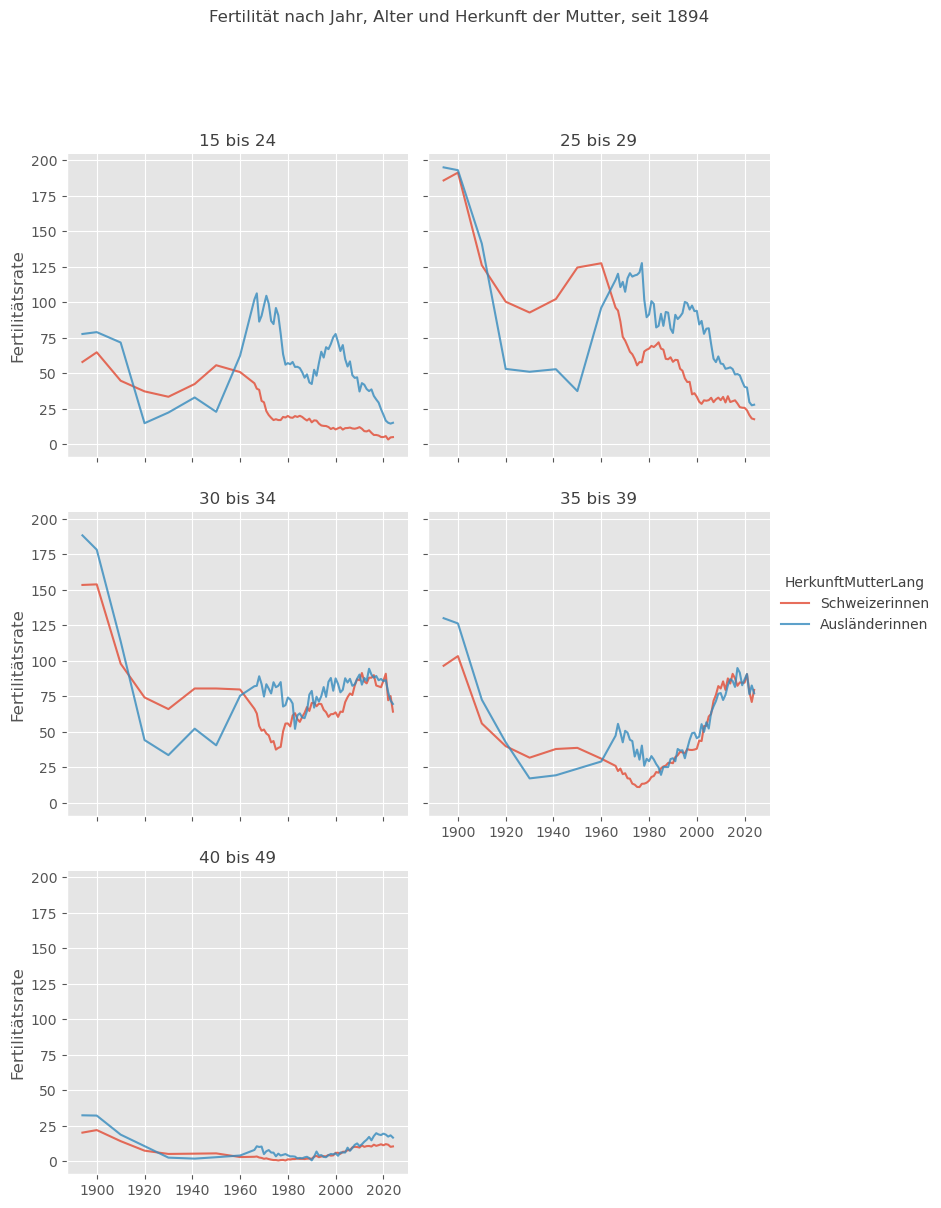

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested[data2betested['ThemaCd']==1].reset_index().sort_values('AlterVMutterKlasseLang')
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Fertilitaetsrate_noDM"
    ,ylabel= "Fertilitätsrate"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Fertilität nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [ ]:
data2betested.columns

Index(['ThemaCd', 'ThemaLang', 'HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd',
       'AlterVMutterKlasseLang', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

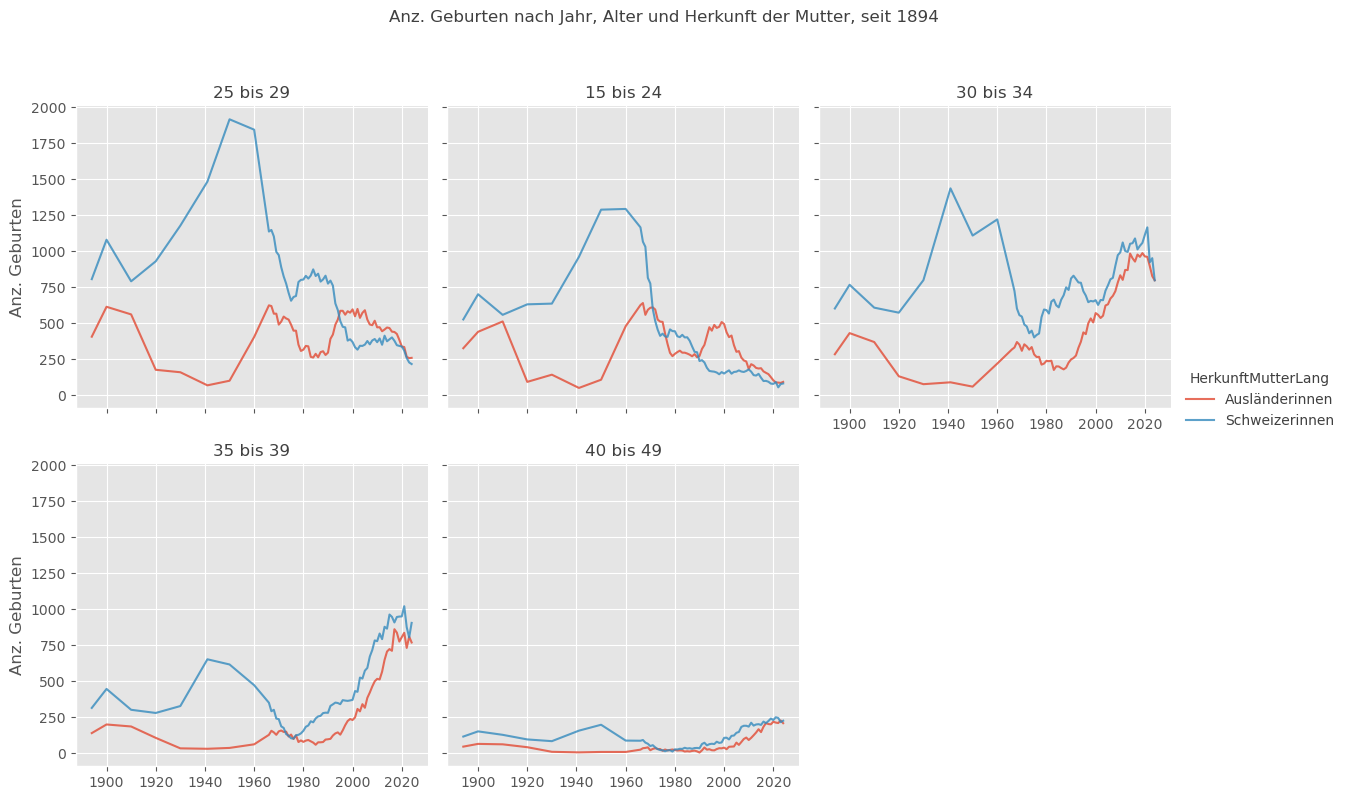

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested[data2betested['ThemaCd']==1].reset_index()
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzGebuWir"
    ,ylabel= "Anz. Geburten"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anz. Geburten nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

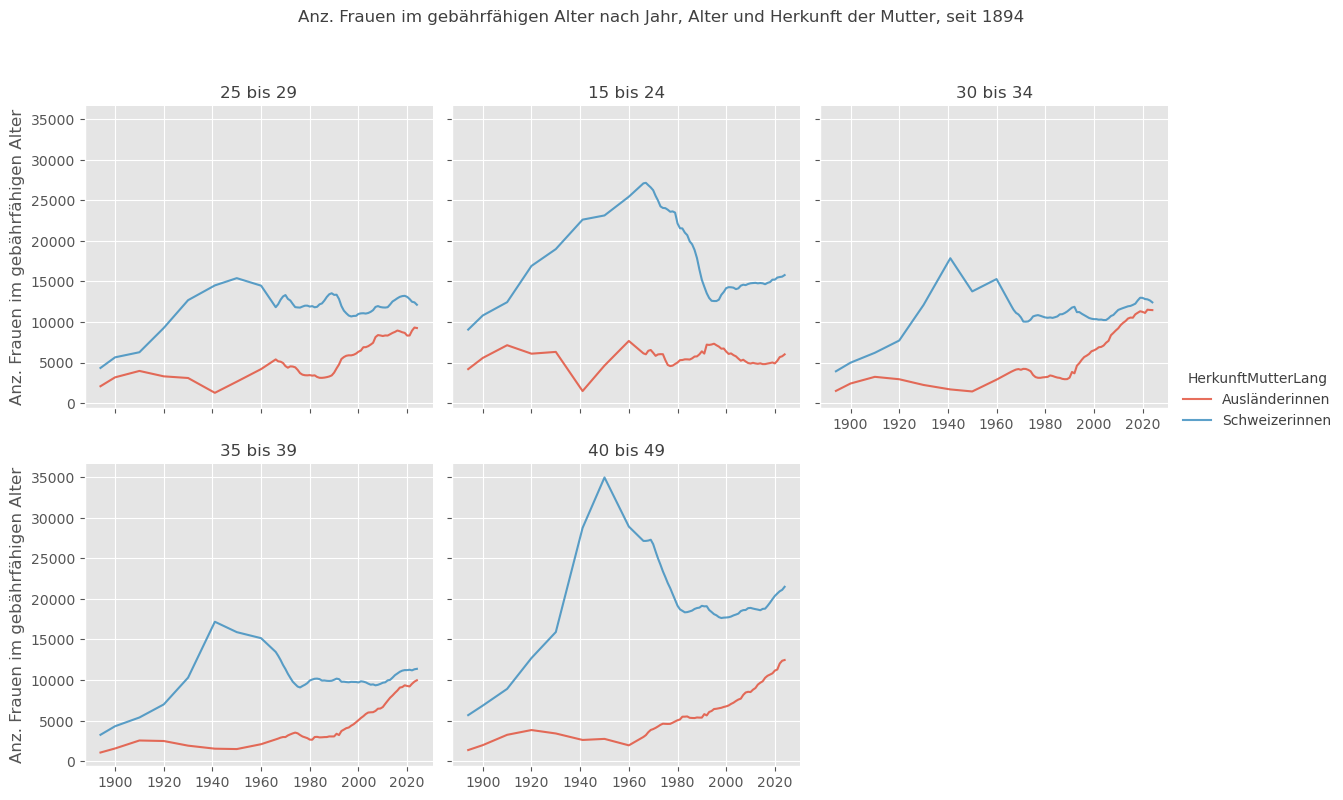

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested[data2betested['ThemaCd']==1].reset_index()
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Frauen15bis49_noDM"
    ,ylabel= "Anz. Frauen im gebährfähigen Alter"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [ ]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['AlterVMutterKlasseLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'ohne Altersklasse': '#0017BF', '15 bis 24': '#0072D7', '25 bis 29': '#00A5D2', '30 bis 34': '#5E359A', '35 bis 39': '#BA0062', '40 bis 49': '#DA5563'}


##### Aufschlüssellung im aktuellsten Jahr

In [ ]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data2betested.index.max()].reset_index()
    ,levels=['ThemaLang','HerkunftMutterLang','AlterVMutterKlasseLang']
    ,values="Fertilitaetsrate_noDM"
    ,color="AlterVMutterKlasseLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fertilitätsrate, "+str(data2betested.index.max())
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001E8810FE7D0>, 'ThemaLang', 'HerkunftMutterLang', 'AlterVMutterKlasseLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1565&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7BCEAF2600%2D5498%2D413B%2D88AA%2DBEE20C2F4F2F%7D%23InplviewHashceaf2600%2D5498%2D413b%2D88aa%2Dbee20c2f4f2f%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------